In [4]:
name = "Elena Vezenkoska"
id = 2600210

In [5]:
# Select the data file based on your student ID
n = id % 5 # Take the modulo 5 of your student ID
num_list = [3, 4, 6, 8, 9] # List of numbers to select from
filename = f'./data/bidmc_{num_list[n]:02d}_Signals.csv'
print(f'Filename: {filename}')

Filename: ./data/bidmc_03_Signals.csv


In [6]:
# Run if needed
#%pip install numpy pandas matplotlib scipy

In [7]:
# Read necessary libraries and functions
import numpy as np                  # for numerical operations
import matplotlib.pyplot as plt     # for plotting
import pandas as pd                 # for reading data
from scipy.signal import find_peaks # for peak detection
import os                           # for file operations

In [8]:
# Print the list of files in the ./data directory
os.listdir('./data')

['bidmc_02_Fix.txt',
 'bidmc_02_Signals.csv',
 'bidmc_03_Fix.txt',
 'bidmc_03_Signals.csv',
 'bidmc_04_Fix.txt',
 'bidmc_04_Signals.csv',
 'bidmc_06_Fix.txt',
 'bidmc_06_Signals.csv',
 'bidmc_08_Fix.txt',
 'bidmc_08_Signals.csv',
 'bidmc_09_Fix.txt',
 'bidmc_09_Signals.csv']

In [9]:
# Read the data
data = pd.read_csv(filename)

# Get PPG signal and create time vector
ppg = data[' PLETH']
ts = 0.008 # Sample time in seconds
fs = 1/ts # Sample rate (Hz), samples per second
t = np.arange(len(ppg))*ts

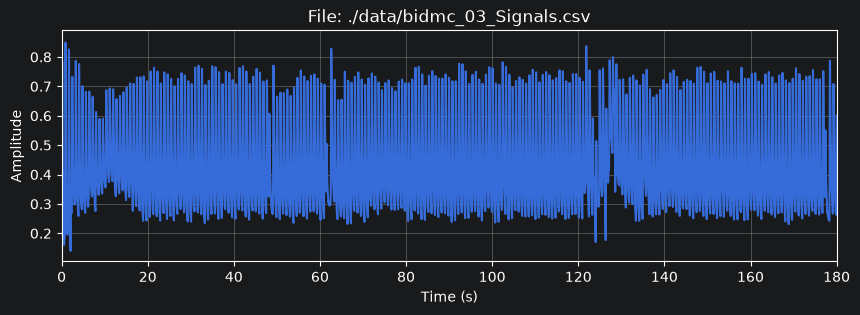

In [10]:
# Plot 180 seconds of the full signal
plt.figure(figsize = (10, 3))
plt.plot(t, ppg)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'File: {filename}')
plt.xlim(0, 180)
plt.grid()
plt.show()

## Find the peaks of the signal

In [11]:
# Find the peaks of the PPG signal
# A height threshold based on the signal's own mean/std makes the detection
# adapt automatically to whichever file is loaded (based on student ID).
# 'distance' sets the minimum number of samples between two peaks, which
# prevents detecting two peaks for a single heartbeat.
height_threshold = ppg.mean() + 0.3 * ppg.std()
min_distance = int(0.35 * fs)  # roughly limits HR to < ~170 bpm

peaks, properties = find_peaks(ppg, height=height_threshold, distance=min_distance)

print(f'Height threshold used: {height_threshold:.3f}')
print(f'Number of peaks detected: {len(peaks)}')


Height threshold used: 0.473
Number of peaks detected: 610


## Plot the detected peaks

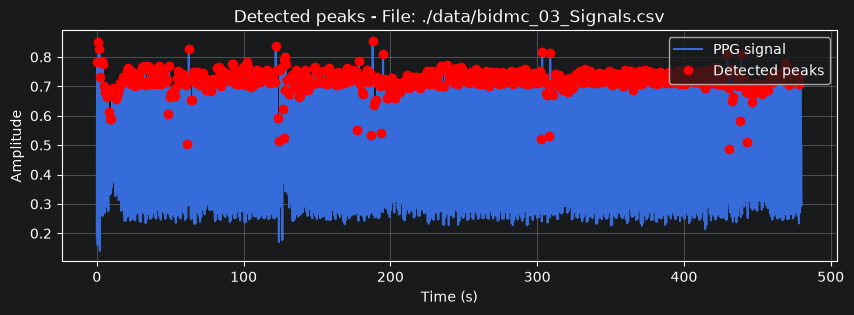

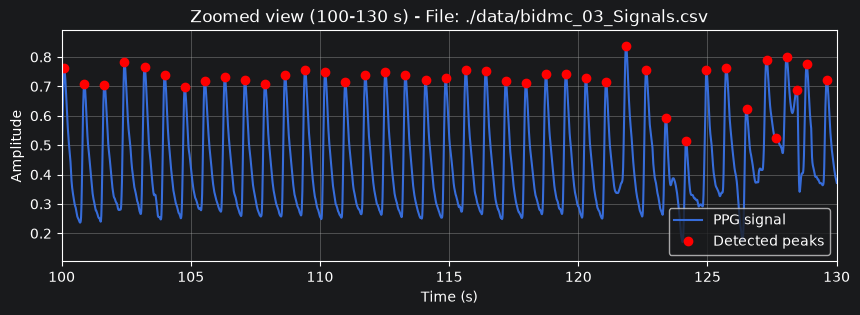

In [12]:
# Plot the full signal together with the detected peaks
plt.figure(figsize=(10, 3))
plt.plot(t, ppg, label='PPG signal')
plt.plot(t[peaks], ppg[peaks], 'ro', label='Detected peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Detected peaks - File: {filename}')
plt.legend()
plt.grid()
plt.show()

# Zoom in on a short window (e.g. 100-130 s) to check the peak detection quality
plt.figure(figsize=(10, 3))
plt.plot(t, ppg, label='PPG signal')
plt.plot(t[peaks], ppg[peaks], 'ro', label='Detected peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Zoomed view (100-130 s) - File: {filename}')
plt.xlim(100, 130)
plt.legend()
plt.grid()
plt.show()


## Calculate peak-to-peak intervals (PPIs)

In [13]:
# Calculate the peak-to-peak intervals (PPI), in milliseconds
ppi = np.diff(peaks) * ts * 1000  # convert from samples to milliseconds

# Remove physiologically implausible intervals (keeps HR roughly between 40-160 bpm)
# Adjust these bounds if your zoomed-in plot shows genuine beats being removed.
valid = (ppi > 375) & (ppi < 1500)
ppi = ppi[valid]

print(f'Number of PPI values kept: {len(ppi)}')


Number of PPI values kept: 606


## Plot the PPI

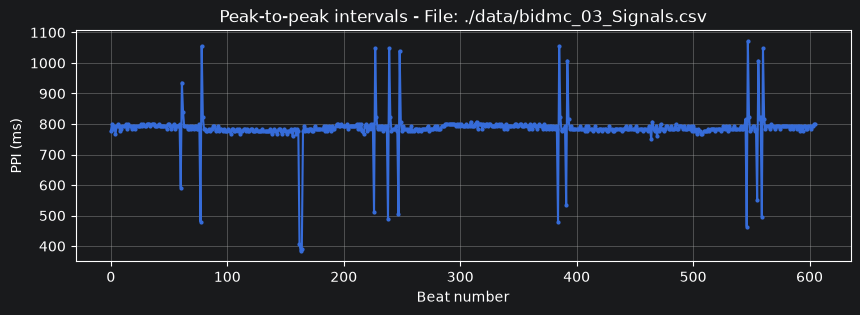

In [14]:
# Plot the PPI values across the recording
plt.figure(figsize=(10, 3))
plt.plot(ppi, marker='o', markersize=2)
plt.xlabel('Beat number')
plt.ylabel('PPI (ms)')
plt.title(f'Peak-to-peak intervals - File: {filename}')
plt.grid()
plt.show()


## Calculate HRV analysis parameters

In [15]:
# Mean PPI (ms)
mean_ppi = np.mean(ppi)

# Mean heart rate (bpm)
mean_hr = 60000 / mean_ppi

# SDNN: standard deviation of the PPI values (ms)
sdnn = np.std(ppi)

# RMSSD: root mean square of successive differences between PPIs (ms)
rmssd = np.sqrt(np.mean(np.diff(ppi) ** 2))

print(f'Mean PPI : {mean_ppi:.2f} ms')
print(f'Mean HR  : {mean_hr:.2f} bpm')
print(f'SDNN     : {sdnn:.2f} ms')
print(f'RMSSD    : {rmssd:.2f} ms')


Mean PPI : 784.99 ms
Mean HR  : 76.43 bpm
SDNN     : 56.08 ms
RMSSD    : 85.48 ms


## Interpretation

*(Run all the cells above first, then replace the bracketed placeholders below with your own printed values and your own interpretation. Compare your numbers against the normal reference ranges given in the lecture notes — the ranges mentioned here are typical resting-adult values and are only a guide.)*

1. **Mean heart rate**: My mean HR was **[value] bpm**. A typical resting adult HR is roughly 60-100 bpm, so my value is [low / normal / high] compared to that range.

2. **Mean PPI**: My mean PPI was **[value] ms**. Since PPI and HR are inversely related (PPI = 60000 / HR), a PPI corresponding to 60-100 bpm is roughly 600-1000 ms, so my value is [low / normal / high].

3. **Variation in PPI (SDNN and RMSSD)**: My SDNN was **[value] ms** and my RMSSD was **[value] ms**. [Describe here whether the beat-to-beat intervals were fairly steady or fluctuated a lot, referring to your PPI plot as well.]

4. **Was the variation low or high?**: Compared to the normal reference values given in the lecture notes, my SDNN/RMSSD were [low / normal / high], which indicates [lower / normal / higher] heart rate variability than typical.

5. **Interpretation of recovery/stress level**: Higher HRV (higher SDNN/RMSSD) generally reflects stronger parasympathetic ("rest and digest") activity and better recovery, while lower HRV is often associated with sympathetic dominance, stress, or reduced recovery. Based on my mean HR, mean PPI, SDNN and RMSSD values compared to the normal ranges, the patient's data suggests [interpretation - e.g. a relaxed/resting state, or a stressed/aroused state, or an active/exercising state]. [Add one or two sentences justifying this conclusion using your specific numbers.]
